<a href="https://colab.research.google.com/github/shiningarmor244/Struktur_Data_smt2/blob/main/Praktikum_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Instalisasi Library

!pip install networkx matplotlib

# networkx → library untuk membuat dan mengolah graph
# matplotlib → library untuk menaampilkan visualisasi graph

In [3]:
# Struktur data graf dan algoritma

import heapq # heapq → membuat priority queue.
# nilai paling kecil akan diproses pertama
# Dijkstra selalu mengambil jarak terkecil atau terpendek
import networkx as nx # membaut dan mengelola graph
import matplotlib.pyplot as plt # menampilkan visualisai graph

def dijkstra_with_paths(graph, start): # start → node awal pencarian
    distances = {node: float('inf') for node in graph} # dictionary distance
    distances[start] = 0 # jarak node awal ke diri sendiri
    previous = {node: None for node in graph} # previous → menyimpan node sebelumnya
    queue = [{0, start}] # membuat priority queue
    # isi: (jarak, node)

    while queue:
        current_distance, current_node = heapq.heappop(queue) # mengambil data jarak paling pendek
        # current_distance → jarak sekarang
        # current_node →node yang sedang diproses

        for neighbor, weight in graph[current_node].items(): # mengambil semua tetangga
        # weight → bobot/jarak antar node
            distance = current_distance + weight # menghitung total jarak baru
            # rumus: jarang sekarang + bobot edge
            # edge → garis penghubung antar node
            if distance < distances [neighbor]: # megecek jarak baru apakah lebih kecil
                distances[neighbor] = distance # memperbarui jarak terpendek
                previous[neighbor] = current_node # mnyimpan node sebelumnya
                heapq.heappush(queue, (distance, neighbor))

    return distances, previous # mengembalikan:
    # distances → semua jarak terpendek
    # previous → jalur sebelumnya


In [4]:
# Fungsi untuk merekonstruksi jalur
 # rekonstruksi jalur → proses menyusun kembali jalur terpendek dari node awal sampai tujuan
 # menggunakan data previous

def get_path(previous, target): # previous → menyimpan node sebelimnya dari hasil Dijkstra
                      # target → node tujuan akhir
    path = []
    while target is not None: # None → sudah sampai node awal
        path.insert(0, target) # memasukkan node kedalam list
        # insert(0, ...) → data dimasukkan dari depan → pelacakan dimulai dari node tujuan menuju node awal
        # supaya ahsilnya tetap urut dari awal → tujuan
        target = previous[target] # pindah ke node sebelumnya
    return path

In [5]:
# visualisasi dengan networkx dan matplotlib

def visualize_graph(graph, path=None): # graph → data graf
                          # path → jalur terpendek yang ingin diberi warna khusus
    G = nx.DiGraph() # membuat graph berarah (Directed Graph)
    # DiGraph artinya: graph memiliki arah
    # contoh: A → B berbeda dengan B → A

    for node in graph: # mengambil setiap node dalam graph
        for neighbor, weight in graph[node].items(): # mengambil semua tetangga dan bobotnya
            G.add_edge(node, neighbor, weight=weight)  # menambahkan edge/sisi ke graph
            # contoh: A → B dengan bobot 4

    pos = nx.spring_layout(G) # mengatur posisi node secara ototmatis
    # spring_layout → tampilan grah lebih rapi
    # posisi node dihitung otomatis
    edge_labels = nx.get_edge_attributes(G, 'weight') # mengambil semua label bobot edge
    # weight → sebagai labelangla pada garis

    plt.figure(figsize=(8, 6)) # mengatur ukuran tampilan grafik
    # figsize=(8,6)
    # artinya: lebar = 8, tinggi = 6
    nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=200, font_weight='bold', arrows=True)
    # menggambar graph
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels) # menampilkan jarak pada edge

    # Garis tebal untuk jalur terpendek
    if path and len(path) > 1: #
        path_edges = list(zip(path, path[1:]))
        nx.draw_networkx_edges(G, pos, edgelist=path_edges, edge_color='red', width=3)

    plt.title("Visualisasi Graf dan Jalur Terpendek")
    plt.axis('off')
    plt.show()

Jarak dari A ke Z : 14
Jalur: A→B→D→E→Z


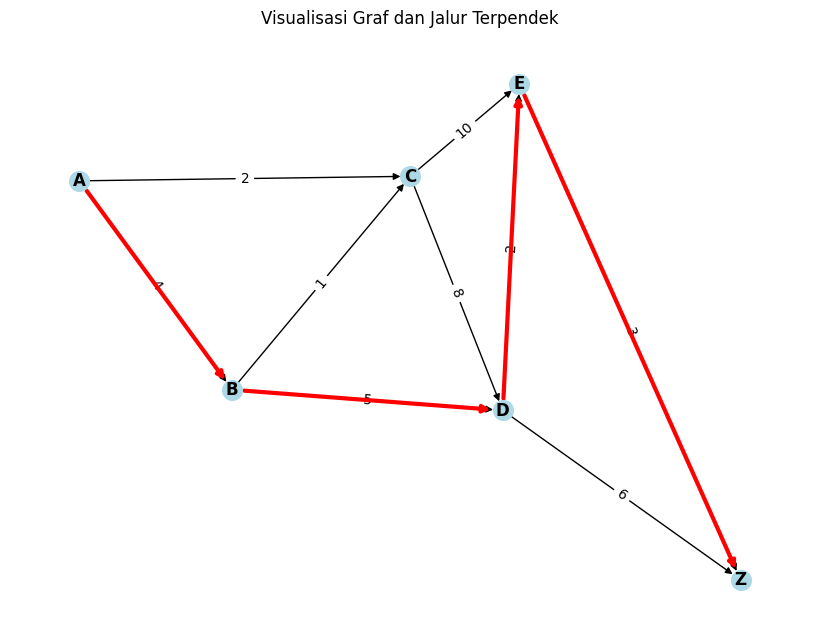

In [6]:
# Penggunaan lengkap

# Definisi Graf

graph = {       # Digunakan untuk membuat graf berbobot
    'A' : {'B': 4, 'C': 2}, # huruf A, B, C → node/simpul
    'B' : {'C': 1, 'D': 5}, # 4, 2, 5 → boboot/jarak
    'C' : {'D': 8, 'E': 10},
    'D' : {'E': 2, 'Z': 6},
    'E' : {'Z': 3},
    'Z' : {}
}

# Jalankan Djikstra

start_node = 'A' # menentukan titik awal pencarian jalur
end_node = 'Z' # menentukan node tujuan
distances, previous = dijkstra_with_paths(graph, start_node) # menjalankan algoritma → menyimpan jarak terpendek dari node wal ke setiap node

# Rekonstruksi jalur
shortest_path = get_path(previous, end_node) # menyusun kembali jalur terpendek
print(f"Jarak dari {start_node} ke {end_node} : {distances[end_node]}") # menampilkan total jarak terpendek
print(f"Jalur: {'→'.join(shortest_path)}") # menampilkan urutan ode yang dilalaui

# Visualisasi
visualize_graph(graph, path=shortest_path) # menampilkan gambar graf dimana:

# Node ditampilkan sebagai lingkaran.
# Bobot ditampilkan pada setiap edge.
# Jalur terpendek diberi warna merah (jika fungsi visualisasi sudah diatur demikian).

Jarak dari A ke Z : 14
Jalur: A→B→D→E→Z


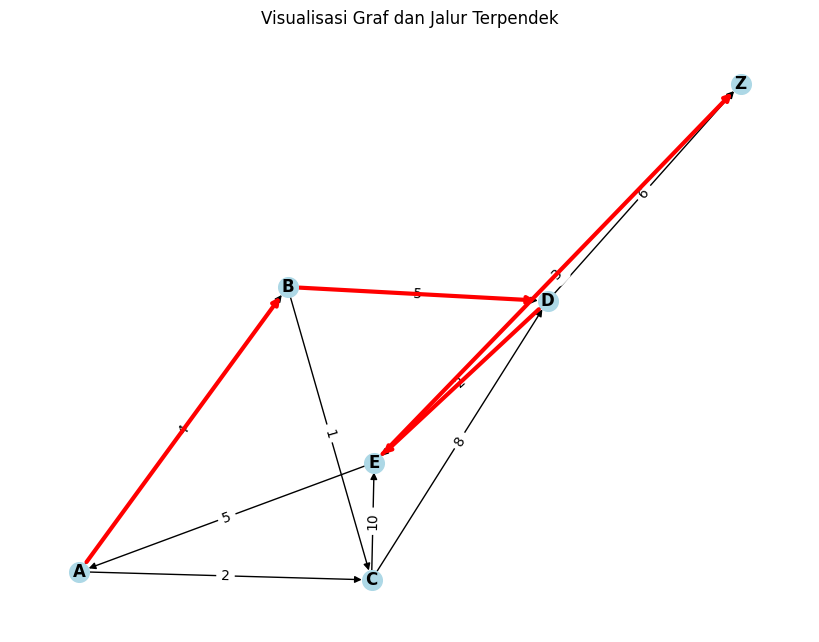

In [9]:
# TUGAS

# Modifikasi graf agar memiliki siklus dan ulangi visualisasinya.
# Tambahkan simpul baru dan lihat bagimana jalur terpendek berubah
# Ganti tata letak graf dengan pos = nx.circular_layout(G) atau kamada_kawai_layout.


# 1. Modiifikasi graf memiliki siklus
graph = {
    'A': {'B': 4, 'C': 2},
    'B': {'C': 1, 'D': 5},
    'C': {'D': 8, 'E': 10},
    'D': {'E': 2, 'Z': 6},
    'E': {'Z': 3, 'A': 5},  # tambahan edge ke A
    'Z': {}
}

# Jalankan Djikstra

start_node = 'A' # menentukan titik awal pencarian jalur
end_node = 'Z' # menentukan node tujuan
distances, previous = dijkstra_with_paths(graph, start_node) # menjalankan algoritma → menyimpan jarak terpendek dari node wal ke setiap node

# Rekonstruksi jalur
shortest_path = get_path(previous, end_node) # menyusun kembali jalur terpendek
print(f"Jarak dari {start_node} ke {end_node} : {distances[end_node]}") # menampilkan total jarak terpendek
print(f"Jalur: {'→'.join(shortest_path)}") # menampilkan urutan ode yang dilalaui

# Visualisasi
visualize_graph(graph, path=shortest_path) # menampilkan gambar graf dimana:

# Node ditampilkan sebagai lingkaran.
# Bobot ditampilkan pada setiap edge.
# Jalur terpendek diberi warna merah (jika fungsi visualisasi sudah diatur demikian).

Jarak dari A ke Z : 5
Jalur: A→C→X→Z


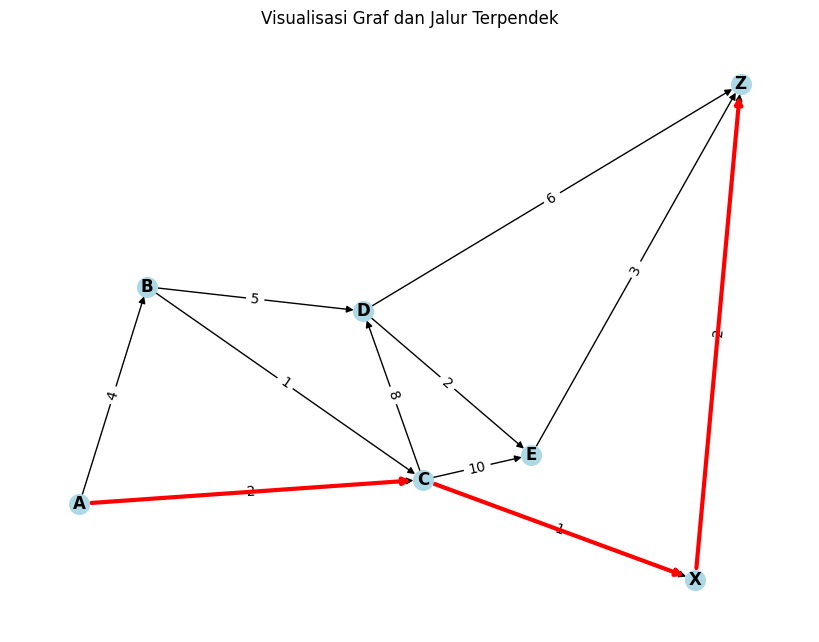

In [11]:
# 2. Menambahkan simpul baru dan jalur terpendek akakn berubah.

graph = {
    'A': {'B': 4, 'C': 2},
    'B': {'C': 1, 'D': 5},
    'C': {'D': 8, 'E': 10, 'X': 1},
    'D': {'E': 2, 'Z': 6},
    'E': {'Z': 3},
    'X': {'Z': 2}, # Menambahkan node baru bernama X
    'Z': {}
}

# Jalankan Djikstra

start_node = 'A' # menentukan titik awal pencarian jalur
end_node = 'Z' # menentukan node tujuan
distances, previous = dijkstra_with_paths(graph, start_node) # menjalankan algoritma → menyimpan jarak terpendek dari node wal ke setiap node

# Rekonstruksi jalur
shortest_path = get_path(previous, end_node) # menyusun kembali jalur terpendek
print(f"Jarak dari {start_node} ke {end_node} : {distances[end_node]}") # menampilkan total jarak terpendek
print(f"Jalur: {'→'.join(shortest_path)}") # menampilkan urutan ode yang dilalaui

# Visualisasi
visualize_graph(graph, path=shortest_path) # menampilkan gambar graf dimana:

# Setelah node baru X ditambahkan, muncul jalur baru yang lebih pende menuju Z
# Jalur terpendek berubah dari 14 menjadi 5

Jarak dari A ke Z : 14
Jalur: A→B→D→E→Z


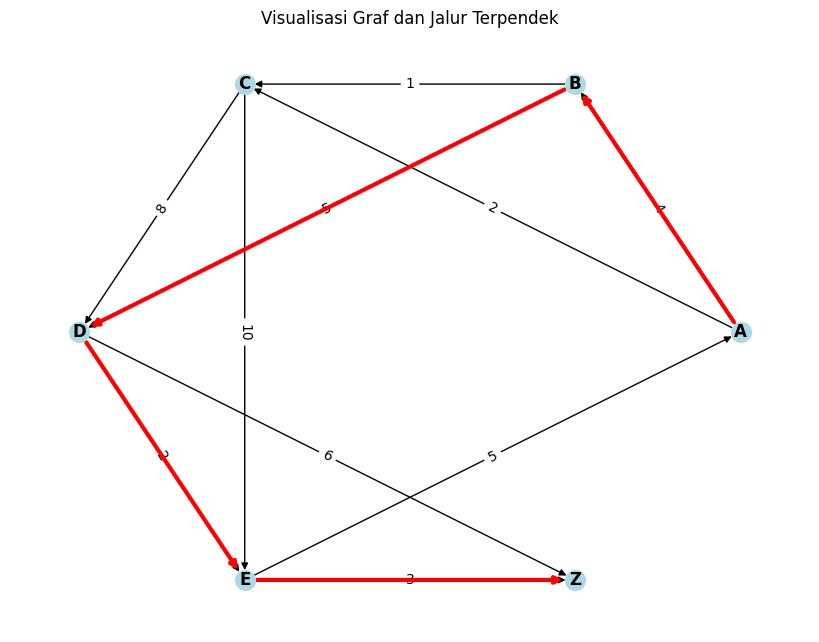

In [13]:
# Mengganti tata letak Graf
# visualisasi dengan networkx dan matplotlib

def visualize_graph(graph, path=None): # graph → data graf
                          # path → jalur terpendek yang ingin diberi warna khusus
    G = nx.DiGraph() # membuat graph berarah (Directed Graph)
    # DiGraph artinya: graph memiliki arah
    # contoh: A → B berbeda dengan B → A

    for node in graph: # mengambil setiap node dalam graph
        for neighbor, weight in graph[node].items(): # mengambil semua tetangga dan bobotnya
            G.add_edge(node, neighbor, weight=weight)  # menambahkan edge/sisi ke graph
            # contoh: A → B dengan bobot 4

    pos = nx.circular_layout(G) # circular → lingkaran → node akan disusun membentuk lingkaran

    edge_labels = nx.get_edge_attributes(G, 'weight') # mengambil semua label bobot edge
    # weight → sebagai labelangla pada garis

    plt.figure(figsize=(8, 6)) # mengatur ukuran tampilan grafik
    # figsize=(8,6)
    # artinya: lebar = 8, tinggi = 6
    nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=200, font_weight='bold', arrows=True)
    # menggambar graph
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels) # menampilkan jarak pada edge

    # Garis tebal untuk jalur terpendek
    if path and len(path) > 1: #
        path_edges = list(zip(path, path[1:]))
        nx.draw_networkx_edges(G, pos, edgelist=path_edges, edge_color='red', width=3)

    plt.title("Visualisasi Graf dan Jalur Terpendek")
    plt.axis('off')
    plt.show()

    # ------------------------------------------------------------------------------------------------------------------------

# 1. Graf memiliki siklus
graph = {
    'A': {'B': 4, 'C': 2},
    'B': {'C': 1, 'D': 5},
    'C': {'D': 8, 'E': 10},
    'D': {'E': 2, 'Z': 6},
    'E': {'Z': 3, 'A': 5},  # tambahan edge ke A
    'Z': {}
}

# Jalankan Djikstra

start_node = 'A' # menentukan titik awal pencarian jalur
end_node = 'Z' # menentukan node tujuan
distances, previous = dijkstra_with_paths(graph, start_node) # menjalankan algoritma → menyimpan jarak terpendek dari node wal ke setiap node

# Rekonstruksi jalur
shortest_path = get_path(previous, end_node) # menyusun kembali jalur terpendek
print(f"Jarak dari {start_node} ke {end_node} : {distances[end_node]}") # menampilkan total jarak terpendek
print(f"Jalur: {'→'.join(shortest_path)}") # menampilkan urutan ode yang dilalaui

# Visualisasi
visualize_graph(graph, path=shortest_path) # menampilkan gambar graf dimana:

# Node ditampilkan sebagai lingkaran.
# Bobot ditampilkan pada setiap edge.
# Jalur terpendek diberi warna merah (jika fungsi visualisasi sudah diatur demikian).

Jarak dari A ke Z : 14
Jalur: A→B→D→E→Z


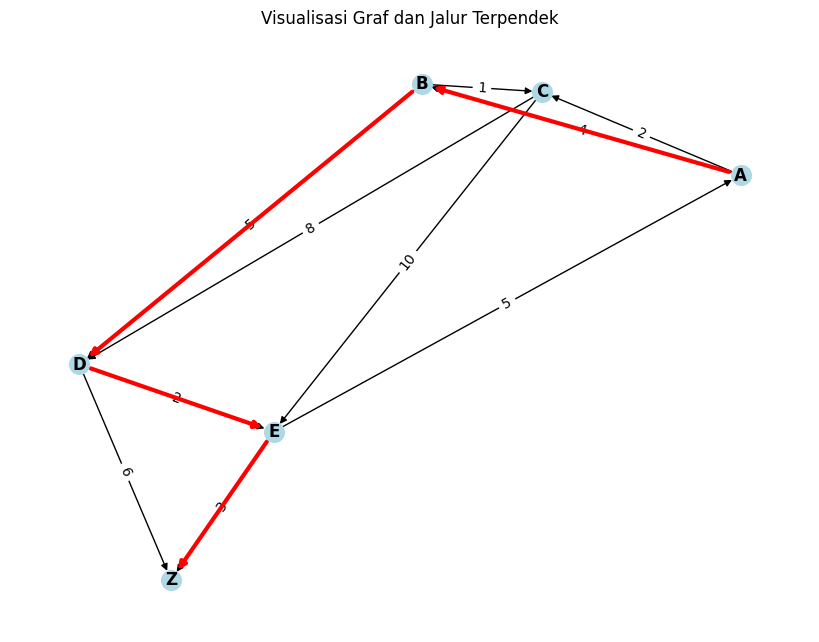

In [14]:
# visualisasi dengan networkx dan matplotlib

def visualize_graph(graph, path=None): # graph → data graf
                          # path → jalur terpendek yang ingin diberi warna khusus
    G = nx.DiGraph() # membuat graph berarah (Directed Graph)
    # DiGraph artinya: graph memiliki arah
    # contoh: A → B berbeda dengan B → A

    for node in graph: # mengambil setiap node dalam graph
        for neighbor, weight in graph[node].items(): # mengambil semua tetangga dan bobotnya
            G.add_edge(node, neighbor, weight=weight)  # menambahkan edge/sisi ke graph
            # contoh: A → B dengan bobot 4

    pos = nx.kamada_kawai_layout(G) # Node akan ditempatkan secara otomatis berdasarkan hubungan antar node
                                    # Graf terlihat lebih seimbang dan mudah dibaca

    edge_labels = nx.get_edge_attributes(G, 'weight') # mengambil semua label bobot edge
    # weight → sebagai labelangla pada garis

    plt.figure(figsize=(8, 6)) # mengatur ukuran tampilan grafik
    # figsize=(8,6)
    # artinya: lebar = 8, tinggi = 6
    nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=200, font_weight='bold', arrows=True)
    # menggambar graph
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels) # menampilkan jarak pada edge

    # Garis tebal untuk jalur terpendek
    if path and len(path) > 1: #
        path_edges = list(zip(path, path[1:]))
        nx.draw_networkx_edges(G, pos, edgelist=path_edges, edge_color='red', width=3)

    plt.title("Visualisasi Graf dan Jalur Terpendek")
    plt.axis('off')
    plt.show()

# ------------------------------------------------------------------------------------------------------------------------


# Graf memiliki siklus
graph = {
    'A': {'B': 4, 'C': 2},
    'B': {'C': 1, 'D': 5},
    'C': {'D': 8, 'E': 10},
    'D': {'E': 2, 'Z': 6},
    'E': {'Z': 3, 'A': 5},  # tambahan edge ke A
    'Z': {}
}

# Jalankan Djikstra

start_node = 'A' # menentukan titik awal pencarian jalur
end_node = 'Z' # menentukan node tujuan
distances, previous = dijkstra_with_paths(graph, start_node) # menjalankan algoritma → menyimpan jarak terpendek dari node wal ke setiap node

# Rekonstruksi jalur
shortest_path = get_path(previous, end_node) # menyusun kembali jalur terpendek
print(f"Jarak dari {start_node} ke {end_node} : {distances[end_node]}") # menampilkan total jarak terpendek
print(f"Jalur: {'→'.join(shortest_path)}") # menampilkan urutan ode yang dilalaui

# Visualisasi
visualize_graph(graph, path=shortest_path) # menampilkan gambar graf dimana:

# Node ditampilkan sebagai lingkaran.
# Bobot ditampilkan pada setiap edge.
# Jalur terpendek diberi warna merah (jika fungsi visualisasi sudah diatur demikian).